In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
df = pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
features = [
    "GrLivArea",
    "BedroomAbvGr",
    "FullBath"
]

target = "SalePrice"

X = df[features]
y = df[target]

print(X.head())

   GrLivArea  BedroomAbvGr  FullBath
0       1710             3         2
1       1262             3         2
2       1786             3         2
3       1717             3         1
4       2198             4         2


In [6]:
print(X.isnull().sum())
print(y.isnull().sum())

GrLivArea       0
BedroomAbvGr    0
FullBath        0
dtype: int64
0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 1168
Testing Samples: 292


In [8]:
model = LinearRegression()

In [9]:
model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [10]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[113410.67255298 305081.87775899 135904.78562983 205424.67564124
 227502.68349004 121157.48079629 205577.98056584 183787.20378269
 121157.48079629 147219.22233196]


In [11]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 35788.061292436294
MSE : 2806426667.247853
RMSE: 52975.71771338122
R² Score: 0.6341189942328371


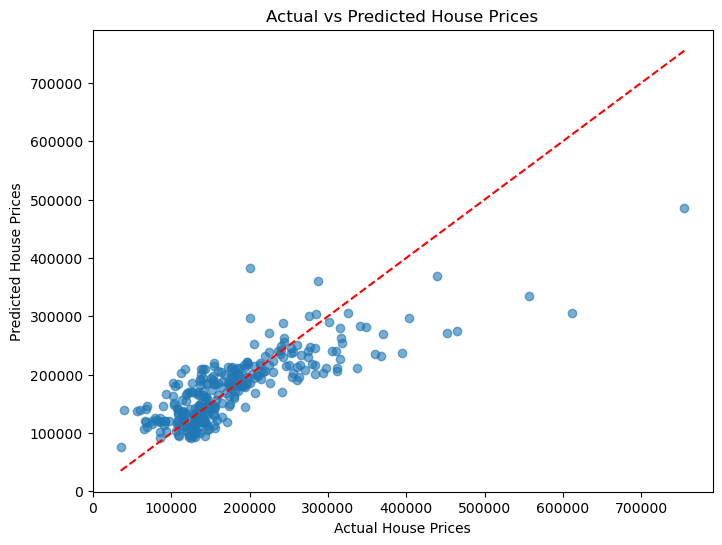

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")

plt.title(
    "Actual vs Predicted House Prices"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

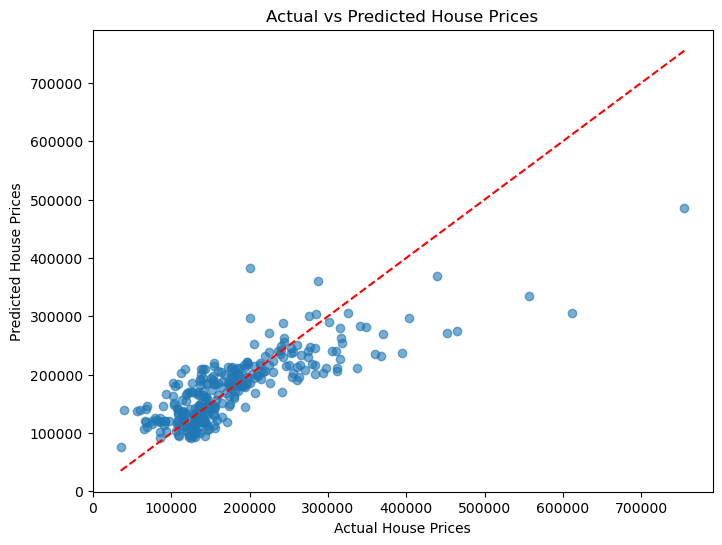

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")

plt.title(
    "Actual vs Predicted House Prices"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.savefig(
    "linear_regression_result.png"
)

plt.show()

In [14]:
square_feet = 2000
bedrooms = 3
bathrooms = 2

house = [[
    square_feet,
    bedrooms,
    bathrooms
]]

prediction = model.predict(house)

print(
    "Predicted House Price: $",
    round(prediction[0], 2)
)

Predicted House Price: $ 240377.51


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [15]:
import joblib

joblib.dump(
    model,
    "house_price_model.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


Conclusion:

A Linear Regression model was developed to predict house prices using square footage, number of bedrooms, and number of bathrooms. The dataset was split into training and testing sets, and the model was evaluated using MAE, RMSE, and R² Score. The results indicate that house size and room count significantly influence house prices, making Linear Regression a suitable baseline model for house price prediction.